In [7]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles (1).csv


In [8]:
# to load the dataset
import pandas as pd
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
#To check the Dataset Information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [70]:
# Count Movies vs TV Shows
print(df['type'].value_counts())

type
Movie      5562
TV Show     189
Name: count, dtype: int64


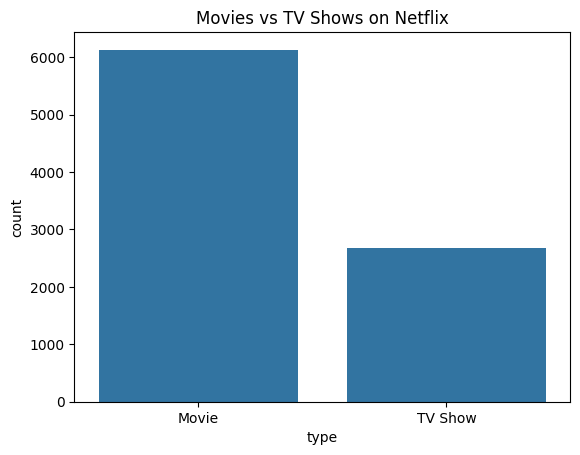

In [11]:
#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='type',data=df)
plt.title("Movies vs TV Shows on Netflix")
plt.show()

In [12]:
# Check Missing Values
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [13]:
# Clean Missing Values
df=df.dropna(subset=['director','country'])
print(df.isnull().sum())

show_id           0
type              0
title             0
director          0
cast            415
country           0
date_added        0
release_year      0
rating            1
duration          3
listed_in         0
description       0
dtype: int64


In [14]:
# Top 10 countries producing netflix content
top_countries=df['country'].value_counts().head(10)
print(top_countries)

country
United States     2048
India              890
United Kingdom     212
Canada             119
Spain              106
Nigeria             90
Egypt               90
Japan               85
France              81
Turkey              79
Name: count, dtype: int64


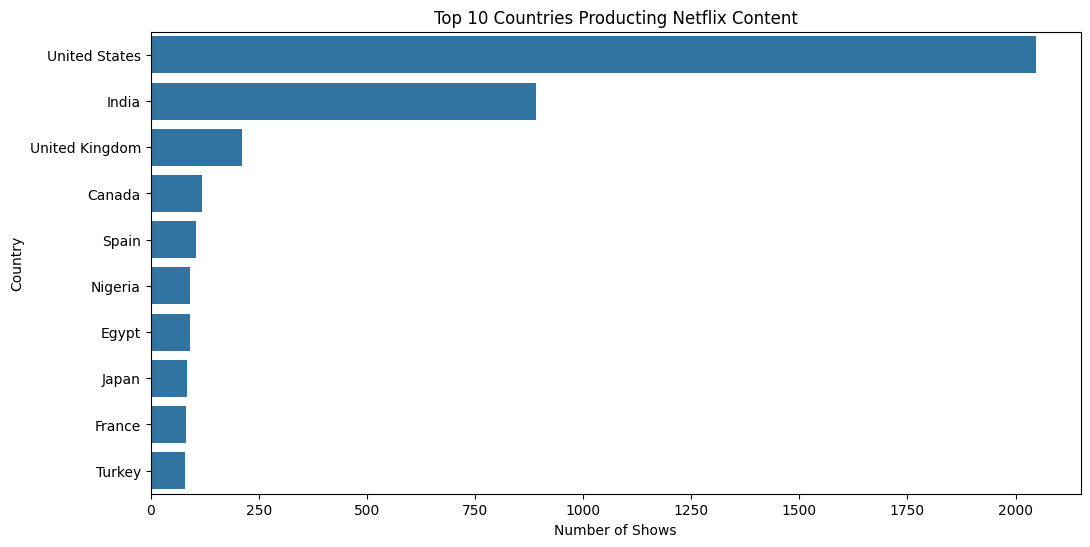

In [15]:
#Visualize Top Countries
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)
plt.title("Top 10 Countries Producting Netflix Content")
plt.xlabel("Number of Shows")
plt.ylabel("Country")
plt.show()

In [16]:
#Most Common ratings
print(df['rating'].value_counts())

rating
TV-MA       1979
TV-14       1330
R            784
TV-PG        505
PG-13        481
PG           281
TV-G         103
TV-Y7         81
TV-Y          79
NR            75
G             41
TV-Y7-FV       3
UR             3
NC-17          2
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


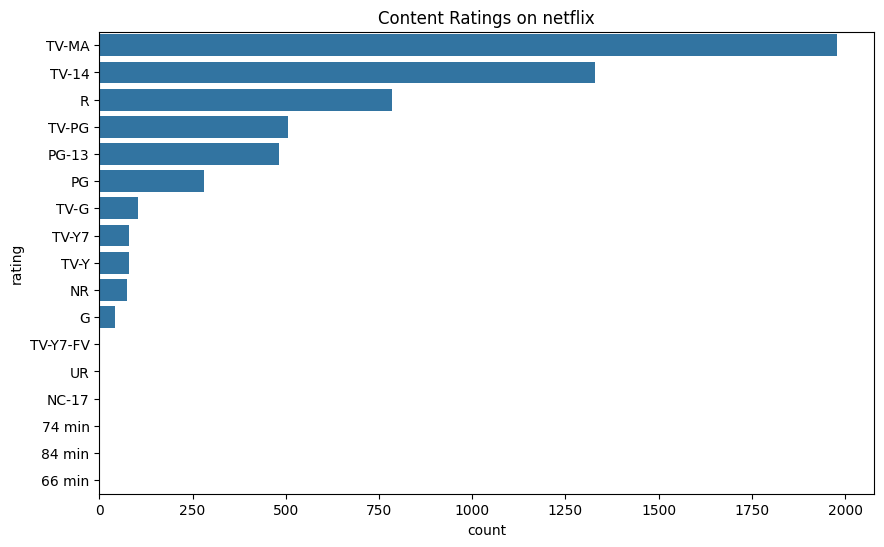

In [17]:
# Rating Visualization
plt.figure(figsize=(10,6))
sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)
plt.title("Content Ratings on netflix")
plt.show()

In [18]:
#Release Year Analysis
release_year = df['release_year'].value_counts().sort_index()
print(release_year.tail())


release_year
2017    736
2018    707
2019    571
2020    488
2021    185
Name: count, dtype: int64


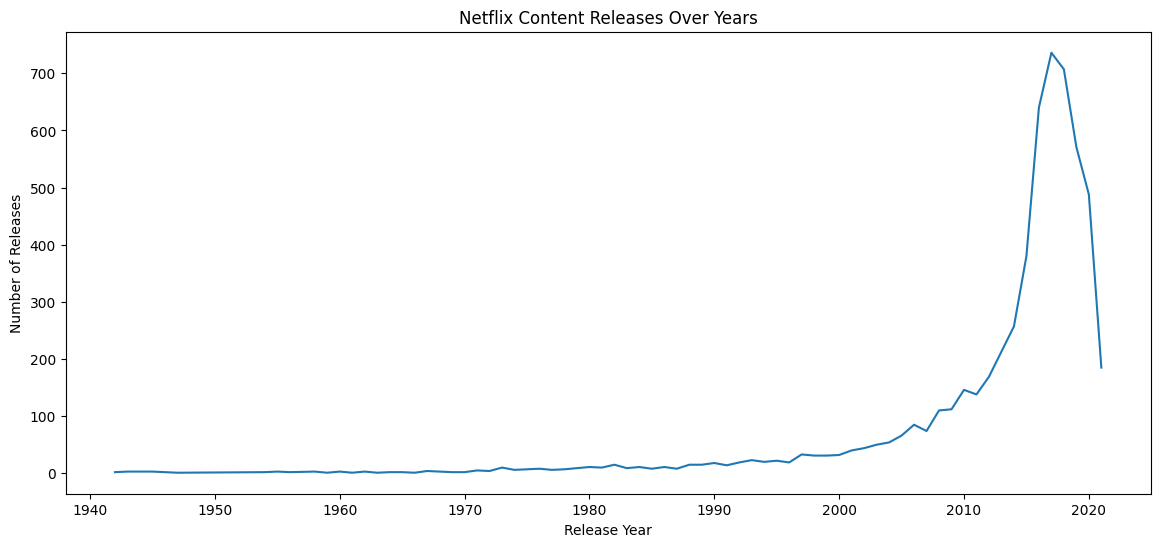

In [19]:
# Release Trend Visualization
plt.figure(figsize=(14,6))
sns.lineplot(
    x=release_year.index,
    y=release_year.values
)
plt.title("Netflix Content Releases Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Releases")
plt.show()

In [20]:
# most Popular Genres
genres=df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
print(top_genres)


listed_in
International Movies        2505
Dramas                      2298
Comedies                    1555
Action & Adventure           809
Documentaries                751
Independent Movies           740
Romantic Movies              580
Thrillers                    547
Children & Family Movies     513
Horror Movies                338
Name: count, dtype: int64


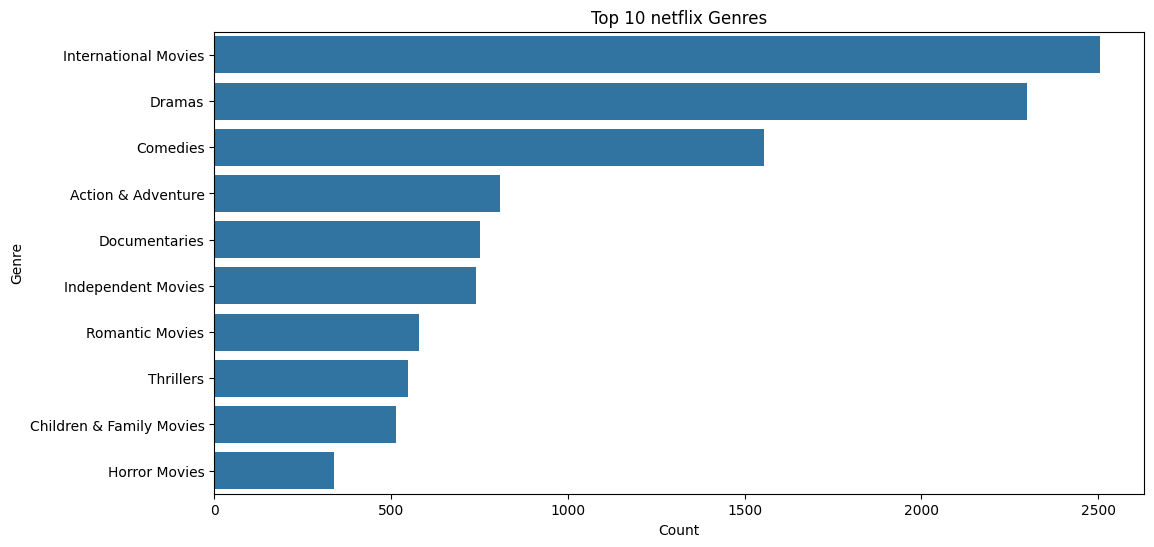

In [21]:
# Genre Visualization
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)
plt.title("Top 10 netflix Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

In [22]:
# DASHBOARD-STYLE VISUALIZATIONS
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
plt.rcParams['figure.figsize']=(12,6)

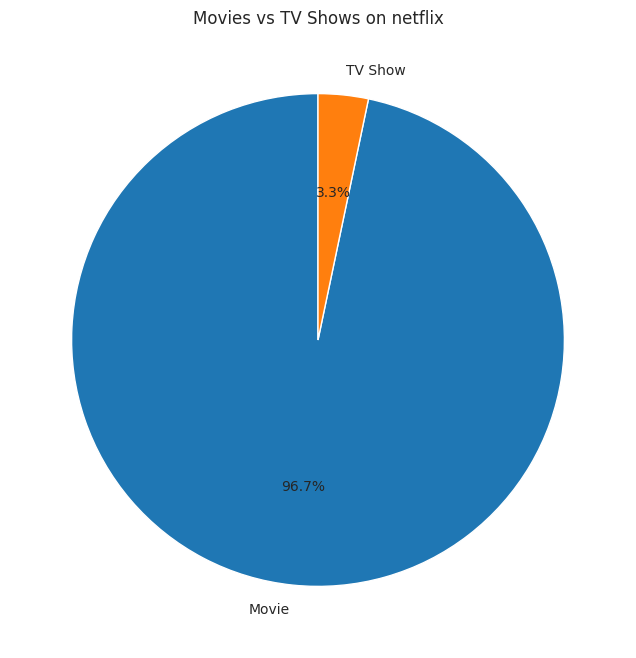

In [23]:
# Movies vs TV shows --Pie Chart
type_counts=df['type'].value_counts()
plt.figure(figsize =(8,8))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct ='%1.1f%%',
    startangle=90
)
plt.title("Movies vs TV Shows on netflix")
plt.show()


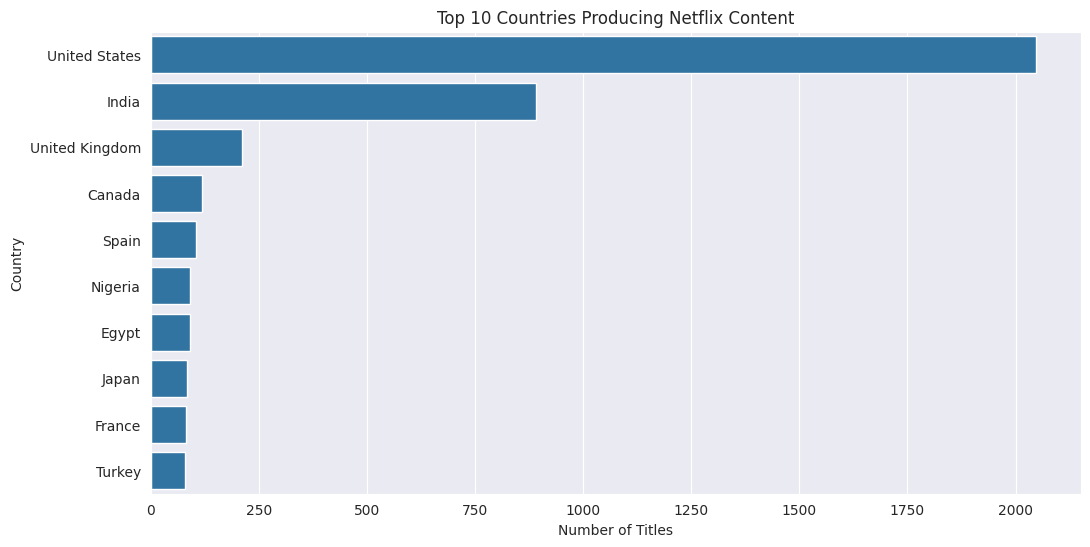

In [24]:
# Top 10 Countries ---Premium Horizontal Chart
top_countries =df['country'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

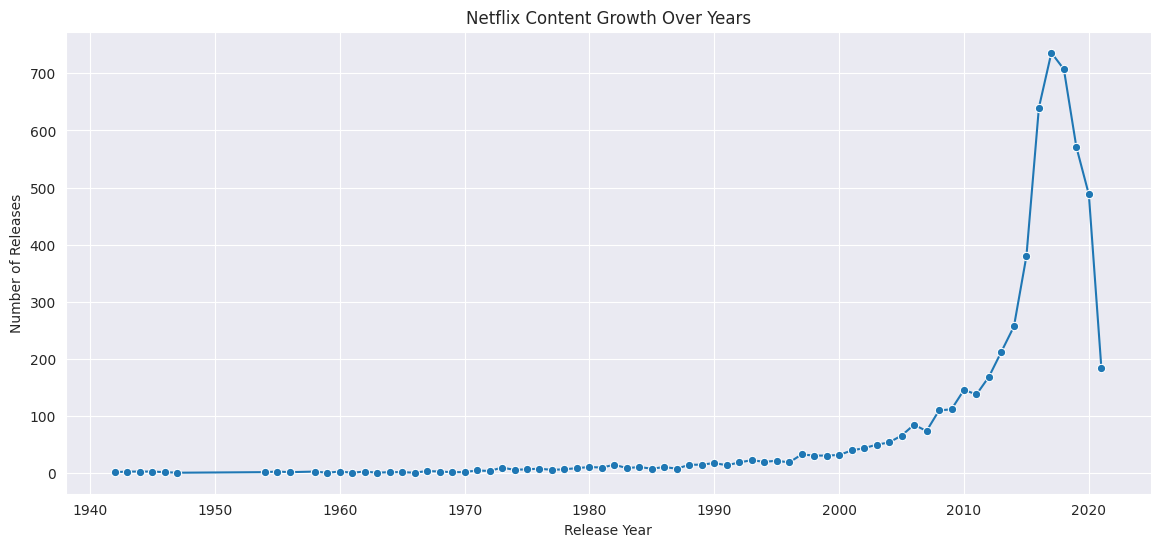

In [25]:
#Netflix growth Over Years --- Smooth Trend Line
release_year=df['release_year'].value_counts().sort_index()
plt.figure(figsize=(14,6))
sns.lineplot(
    x=release_year.index,
    y=release_year.values,
    marker='o'
)
plt.title("Netflix Content Growth Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Releases")
plt.show()

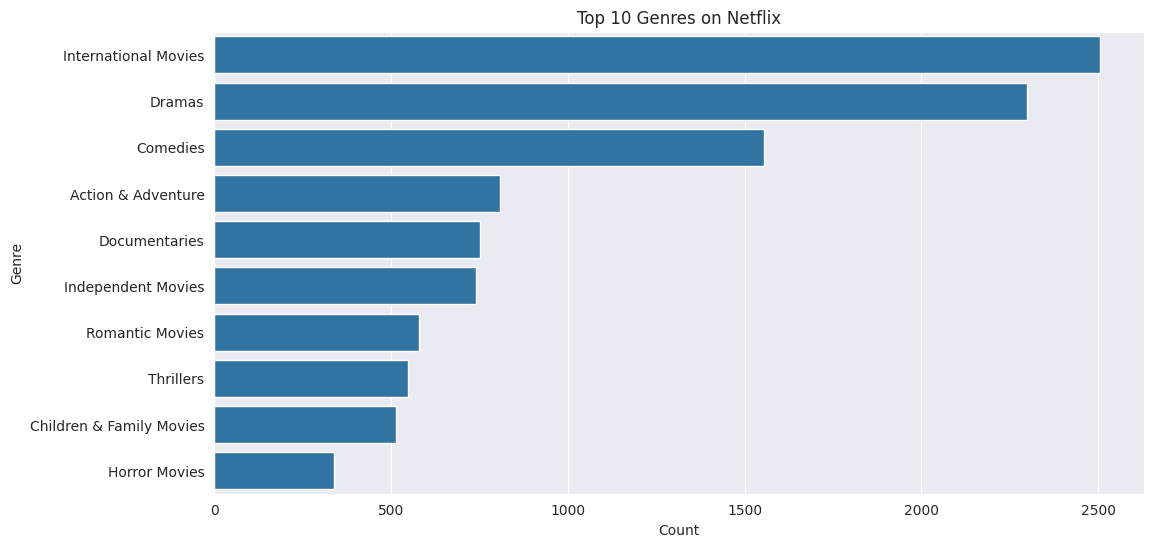

In [26]:
# Top Genres Visualization
genres =df['listed_in'].str.split(', ').explode()
top_genres=genres.value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

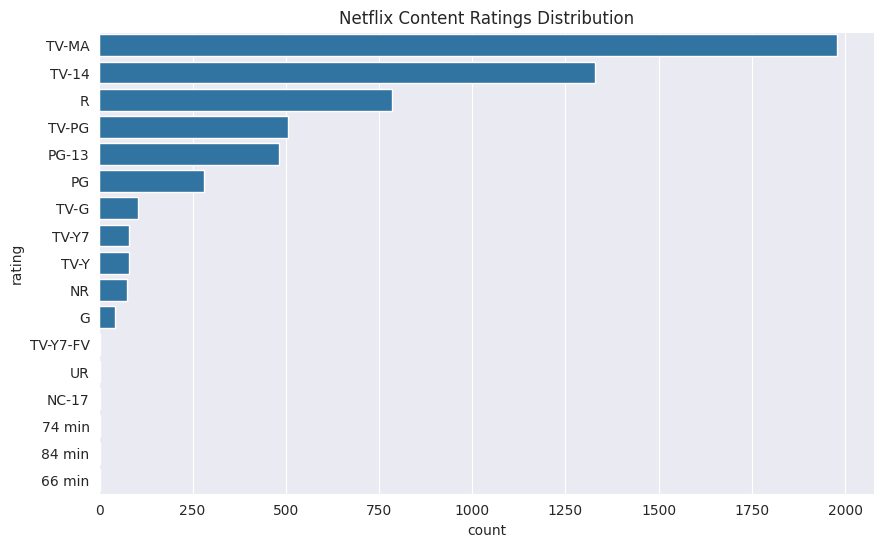

In [27]:
# Content Ratings Distribution
plt.figure(figsize=(10,6))
sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)
plt.title("Netflix Content Ratings Distribution")
plt.show()

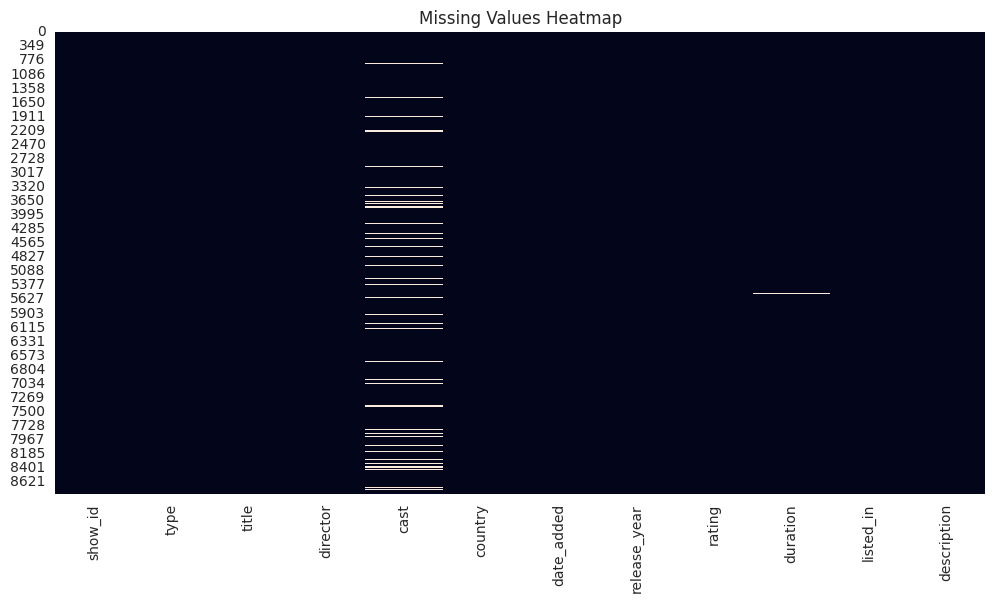

In [28]:
# HEATMAP of MISSING VALUES
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [29]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


## Business Insights

### Business Insight 1
Movies constitute a larger portion of Netflix's content library than TV Shows, indicating stronger investment in movie acquisition and production.

### Business Insight 2
Content releases increased significantly after 2015, highlighting Netflix's rapid global expansion strategy.

### Business Insight 3
Drama and International genres dominate the platform, reflecting diverse audience preferences across regions.

## Key Performance Indicators (KPIs)

In [30]:
total_titles = len(df)

total_movies = len(df[df['type']=="Movie"])

total_tvshows = len(df[df['type']=="TV Show"])

total_countries = df['country'].nunique()

print("Total Titles:", total_titles)
print("Movies:", total_movies)
print("TV Shows:", total_tvshows)
print("Countries:", total_countries)

Total Titles: 5751
Movies: 5562
TV Shows: 189
Countries: 658


In [31]:
import sklearn
print(sklearn.__version__)

1.6.1


# Machine Learning Extension

In [32]:
#Create ML Dataset
ml_df=df[['type','country','release_year','listed_in','rating']].copy()
ml_df.dropna(inplace=True)
ml_df.head()

,type,country,release_year,listed_in,rating
0,Movie,United States,2020,Documentaries,PG-13
7,Movie,"United States, Ghana, Burkina Faso, United Kin...",1993,"Dramas, Independent Movies, International Movies",TV-MA
8,TV Show,United Kingdom,2021,"British TV Shows, Reality TV",TV-14
9,Movie,United States,2021,"Comedies, Dramas",PG-13
12,Movie,"Germany, Czech Republic",2021,"Dramas, International Movies",TV-MA


In [33]:
#Encode Features
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in ml_df.columns:
  ml_df[col]=le.fit_transform(ml_df[col])
ml_df.head()

,type,country,release_year,listed_in,rating
0,0,530,71,214,7
7,0,584,44,245,11
8,1,444,72,90,9
9,0,530,72,158,7
12,0,188,72,252,11


In [34]:
#Split Data
from sklearn.model_selection import train_test_split
X=ml_df.drop('rating',axis=1)
y=ml_df['rating']

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [36]:
# Evaluate
from sklearn.metrics import accuracy_score
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test,predictions)
print("Accuracy:",accuracy)

Accuracy: 0.48


In [37]:
#Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         1
           3       0.75      0.38      0.50         8
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00        19
           6       0.43      0.53      0.48        49
           7       0.45      0.38      0.42        99
           8       0.49      0.42      0.45       156
           9       0.48      0.47      0.48       271
          10       0.06      0.06      0.06        17
          11       0.56      0.63      0.59       414
          12       0.20      0.19      0.20        83
          13       0.80      0.47      0.59        17
          14       0.43      0.40      0.41        15
          15       0.00      0.00      0.00         0

    accuracy                           0.48      1150
   macro avg       0.29   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# Recommendation Engine

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [39]:
# Build Content Features
df['combined_features'] = (
    df['listed_in'].fillna('') +
    df['description'].fillna('')
)

In [40]:
# TF - IDF
tfidf = TfidfVectorizer(stop_words='english')

matrix = tfidf.fit_transform(
    df['combined_features']
)

In [41]:
# Similarity Matrix
similarity =cosine_similarity(matrix)

In [42]:
# Recommendation Function
def recommend(title):
  idx = df[df['title']==title].index[0]

  scores = list(
      enumerate(similarity[idx])
  )
  scores = sorted(
      scores,
      key=lambda x:x[1],
      reverse=True
  )
  for item in scores[1:6]:

    print(
        df.iloc[item[0]]['title']
    )

In [43]:
# Check Whether the Title Exists
df[df['title'].str.contains("Stranger",case=False,na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,combined_features
607,s608,Movie,The Strangers,Bryan Bertino,"Liv Tyler, Scott Speedman, Gemma Ward, Kip Wee...",United States,"July 1, 2021",2008,R,85 min,"Horror Movies, Thrillers",A quiet stay at a remote vacation home spirals...,"Horror Movies, ThrillersA quiet stay at a remo..."
962,s963,Movie,The Strangers: Prey at Night,Johannes Roberts,"Bailee Madison, Martin Henderson, Emma Bellomy...","United States, United Kingdom","April 30, 2021",2018,R,85 min,Horror Movies,Home-invasion horror comes to the trailer park...,Horror MoviesHome-invasion horror comes to the...
1089,s1090,Movie,Two Distant Strangers,"Travon Free, Martin Desmond Roe","Joey Bada$$, Andrew Howard, Zaria",United States,"April 9, 2021",2021,TV-MA,32 min,Dramas,"In this Oscar-nominated short film, a man tryi...","DramasIn this Oscar-nominated short film, a ma..."
7728,s7729,Movie,Perfect Stranger,James Foley,"Halle Berry, Bruce Willis, Giovanni Ribisi, Ri...",United States,"January 1, 2019",2007,R,109 min,Thrillers,Ro risks her life to discover the identity of ...,ThrillersRo risks her life to discover the ide...
8101,s8102,Movie,Stranger than Fiction,Marc Forster,"Will Ferrell, Maggie Gyllenhaal, Dustin Hoffma...","United States, United Kingdom","October 1, 2020",2006,PG-13,113 min,"Comedies, Romantic Movies",As a writer ponders how to kill off her main c...,"Comedies, Romantic MoviesAs a writer ponders h..."


In [44]:
#Check Sample titles
df['title'].head(20)

,title
0,Dick Johnson Is Dead
7,Sankofa
8,The Great British Baking Show
9,The Starling
12,Je Suis Karl
24,Jeans
27,Grown Ups
28,Dark Skies
29,Paranoia
38,Birth of the Dragon


In [45]:
# Recommend a known title
recommend("Birth of the Dragon")

One Night Stand
Jackie Brown
Air Force One
Hazaaron Khwaishein Aisi
Rogue City


In [46]:
#Improved Recommend function
def recommend(title):

    matches = df[df['title'].str.lower() == title.lower()]

    if len(matches) == 0:
        print(f"'{title}' not found in dataset.")
        return

    idx = matches.index[0]

    scores = list(enumerate(similarity[idx]))

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    print(f"\nTop recommendations for '{title}':\n")

    for item in scores[1:6]:
        print(df.iloc[item[0]]['title'])

In [47]:
#Test with a known title
print(df['title'].head())

0              Dick Johnson Is Dead
7                           Sankofa
8     The Great British Baking Show
9                      The Starling
12                     Je Suis Karl
Name: title, dtype: object


In [48]:
# Test
recommend("Dick Johnson Is Dead")


Top recommendations for 'Dick Johnson Is Dead':

End Game
The Soul
Black Snake Moan
The Cloverfield Paradox
Moon


In [49]:
# Debug Check
print(df['title'].head(10))

0              Dick Johnson Is Dead
7                           Sankofa
8     The Great British Baking Show
9                      The Starling
12                     Je Suis Karl
24                            Jeans
27                        Grown Ups
28                       Dark Skies
29                         Paranoia
38              Birth of the Dragon
Name: title, dtype: object


In [50]:
recommend("Dick Johnson Is Dead")


Top recommendations for 'Dick Johnson Is Dead':

End Game
The Soul
Black Snake Moan
The Cloverfield Paradox
Moon


In [51]:
df.to_csv(
    "netflix_cleaned.csv",
    index=False
)

In [52]:
from google.colab import files
files.download("netflix_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
!pip install langchain langgraph langchain-community openai pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [54]:
df.to_csv("netflix_cleaned.csv",index=False)

In [55]:
# Dataset Query Tool
import pandas as pd

df = pd.read_csv("netflix_cleaned.csv")

def dataset_tool(query):

    query = query.lower()

    if "movies" in query:
        return f"Total Movies: {len(df[df['type']=='Movie'])}"

    elif "tv shows" in query:
        return f"Total TV Shows: {len(df[df['type']=='TV Show'])}"

    elif "countries" in query:
        return df['country'].value_counts().head(5).to_string()

    elif "genres" in query:
        genres = df['listed_in'].str.split(', ').explode()
        return genres.value_counts().head(10).to_string()

    else:
        return "I could not find an answer."

In [56]:
# Recommendation Tool
def recommendation_tool(title):

    matches = df[df['title'].str.lower() == title.lower()]

    if len(matches) == 0:
        return "Title not found."

    idx = matches.index[0]

    scores = list(enumerate(similarity[idx]))

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    for item in scores[1:6]:
        recommendations.append(
            df.iloc[item[0]]['title']
        )

    return recommendations

In [57]:
# Simpple AI analytics Agent
def netflix_agent(user_query):

    query = user_query.lower()

    if "recommend" in query:

        title = user_query.replace(
            "recommend",
            ""
        ).strip()

        return recommendation_tool(title)

    return dataset_tool(query)

# Test Agent

In [58]:
netflix_agent(
    "recommend Dick Johnson Is Dead"
)

['End Game', 'The Soul', 'Black Snake Moan', 'The Cloverfield Paradox', 'Moon']

In [59]:
netflix_agent(
    "top countries"
)

'country\nUnited States     2048\nIndia              890\nUnited Kingdom     212\nCanada             119\nSpain              106'

In [60]:
netflix_agent(
    "top genres"
)

'listed_in\nInternational Movies        2505\nDramas                      2298\nComedies                    1555\nAction & Adventure           809\nDocumentaries                751\nIndependent Movies           740\nRomantic Movies              580\nThrillers                    547\nChildren & Family Movies     513\nHorror Movies                338'

OpenAI-Powered AI Agent

In [61]:
# OpenAI-Powered Agent
import os
os.environ["OPENAI_API_KEY"] = "YOUR_KEY"


In [62]:
!pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 2.9 MB/s eta 0:00:00


In [63]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini"
)

LLM Summary Layer

In [64]:
def analytics_summary(question):

    result = dataset_tool(question)

    return f"""
Analytics Report
----------------
Query : {question}

Result:
{result}

Business Insight:
The above results highlight the most significant patterns in the Netflix dataset and can support strategic decisions regarding content acquisition and audience preferences.
"""

In [65]:
analytics_summary("top genres")

'\nAnalytics Report\n----------------\nQuery : top genres\n\nResult:\nlisted_in\nInternational Movies        2505\nDramas                      2298\nComedies                    1555\nAction & Adventure           809\nDocumentaries                751\nIndependent Movies           740\nRomantic Movies              580\nThrillers                    547\nChildren & Family Movies     513\nHorror Movies                338\n\nBusiness Insight:\nThe above results highlight the most significant patterns in the Netflix dataset and can support strategic decisions regarding content acquisition and audience preferences.\n'

In [66]:
def dataset_tool(query):

    query = query.lower()

    if "top genres" in query:
        return (
            df['listed_in']
            .str.split(', ')
            .explode()
            .value_counts()
            .head(10)
        )

    elif "movies" in query:
        return df[df['type'] == 'Movie'].shape[0]

    elif "tv shows" in query:
        return df[df['type'] == 'TV Show'].shape[0]

    elif "countries" in query:
        return (
            df['country']
            .dropna()
            .str.split(', ')
            .explode()
            .value_counts()
            .head(10)
        )

    else:
        return "Sorry, I don't understand that query."

In [67]:
dataset_tool("top genres")

,count
listed_in,
International Movies,2505
Dramas,2298
Comedies,1555
Action & Adventure,809
Documentaries,751
Independent Movies,740
Romantic Movies,580
Thrillers,547
Children & Family Movies,513


In [68]:
def analytics_summary(question):

    result = dataset_tool(question)

    report = f"""
==============================
      NETFLIX ANALYTICS REPORT
==============================

Query:
{question}

--------------------------------
Result
--------------------------------
{result}

--------------------------------
Business Insight
--------------------------------
The above results highlight the most significant patterns in the Netflix dataset.
These insights can help Netflix understand customer preferences,
optimize content acquisition, and improve recommendation strategies.
"""

    print(report)

In [69]:
analytics_summary("top genres")


      NETFLIX ANALYTICS REPORT

Query:
top genres

--------------------------------
Result
--------------------------------
listed_in
International Movies        2505
Dramas                      2298
Comedies                    1555
Action & Adventure           809
Documentaries                751
Independent Movies           740
Romantic Movies              580
Thrillers                    547
Children & Family Movies     513
Horror Movies                338
Name: count, dtype: int64

--------------------------------
Business Insight
--------------------------------
The above results highlight the most significant patterns in the Netflix dataset.
These insights can help Netflix understand customer preferences,
optimize content acquisition, and improve recommendation strategies.

